Colab de referência: https://colab.research.google.com/drive/1s0wK-XDQOdUubutjqhJVQL-6q6jKAfy9

In [58]:
from random import random

import pandas as pd

d = {'coluna 1': [1,2], 'coluna 2': [3,4]}

df = pd.DataFrame(data=d)

df

,coluna 1,coluna 2
0,1,3
1,2,4


#### NLTK (*Natural Language Toolkit*)

Biblioteca essencial para o processamento de linguagem natural (NLP), oferecendo ferramentas para análise de texto não supervisionada, como tokenização, *stemming*, e análise de frequências.

In [50]:
from nltk.tokenize import word_tokenize

# Punkt é um algoritmo treinado para separar texto em sentenças (sent_tokenize) e em palavras (word_tokenize).
# Ele contém dados estatísticos que ajudam o NLTK a decidir onde colocar quebras de sentença e como dividir palavras.
# nltk.download('punkt')

# tokenizar
texto = "Olá, como você está hoje?"
tokens = word_tokenize(texto, language='portuguese')
print(tokens)

['Olá', ',', 'como', 'você', 'está', 'hoje', '?']


#### OpenCV
Processamento de imagens e visão computacional, frequentemente utilizada em tarefas não supervisionadas como segmentação de imagem e detecção de bordas.

C:\Users\Pc Gamer\PycharmProjects\pos-NLP\venv\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


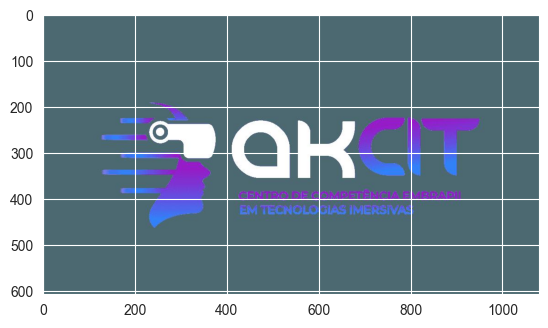

In [22]:
# pip install sickit-image
from skimage import io
import matplotlib.pyplot as plt

# pip install cv2
import cv2

# carregar uma imagem da Internet
image = io.imread('https://akcit.ufg.br/_next/image?url=%2Flogo_akcit.png&w=1080&q=7')

# salvar a imagem localmente
io.imsave('akcit.jpg', image)

# carregar a imagem usando o OpenCV
image = cv2.imread('akcit.jpg')

# corrigir as cores
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.show()

In [ ]:
# importar dados do sickitlearn

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

print(iris.DESCR)

In [25]:
# listar características/colunas
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [26]:
# listar rótulos (classificação)
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [27]:
# apresentar os dados como DataFrame
iris.frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


#### Dados não supervisonados
*Google News Word Vectors*: https://code.google.com/archive/p/word2vec/

Análise de Sentimentos de *Tweets*: https://www.kaggle.com/code/leandrodoze/sentiment-analysis-in-portuguese

Digits Dataset: composto por 1.797 imagens de dígitos manuscritos, cada uma com uma resolução de 8x8 píxeis, em escala de cinza. Disponível no **Scikit-learn**.

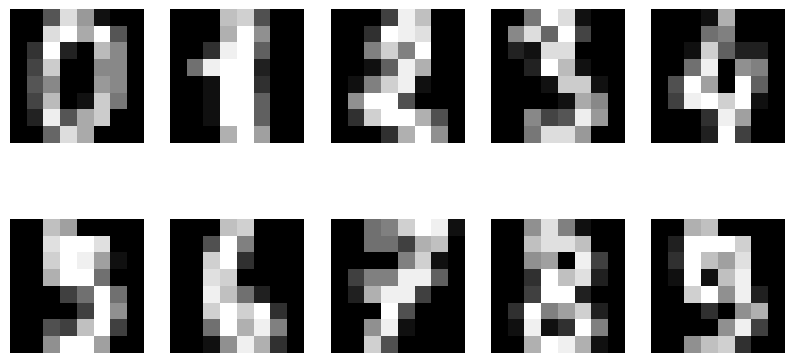

In [47]:
from sklearn import datasets
import matplotlib.pyplot as plt

digits = datasets.load_digits()

data = digits.data

# visualizar algumas imagens, 2 linhas com 5 colunas com figuras de tamanho 10x5
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(data[i].reshape(8, 8), cmap='gray')
    # grade nas imagens
    ax.axis('off')

plt.show()

#### Dados semi-supervisionados

Os dados semi-supervisionados combinam uma **pequena quantidade de dados rotulados** com uma **muitos dados não rotulados**.

Criar conjunto semi-supervisionado a partir do **dataset** Digits:

1 - carregar os dados e os rótulos associados;

2 - embaralhar índices para garantir divisão não sistemática;

3 - manter 10% dos rótulos originais;

4 - rotular os outros 90% com o valor **-1**;

In [75]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
import matplotlib.pylab as plt

digits = load_digits()

# rótulos de classificação
print(digits.target_names)

# características em X
X = digits.data

# rótulos em y
y = digits.target

print(f"Dados das imagens: {X}\n")
print(f"Dados dos rótulos: {y}")
print(f"Tamanho das imagens: {X.shape}")
print(f"Tamanho dos rótulos: {y.shape}")

[0 1 2 3 4 5 6 7 8 9]
Dados das imagens: [[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]

Dados dos rótulos: [0 1 2 ... 8 9 8]
Tamanho das imagens: (1797, 64)
Tamanho dos rótulos: (1797,)


In [81]:
# quantidade de instâncias por rótulo
y_original = pd.DataFrame(data=y, columns=['y_original'])
y_original.groupby('y_original')['y_original'].count()

y_original
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: y_original, dtype: int64

In [85]:
# embaralhar o dataset
random_state = np.random.RandomState(42)
indices = np.arange(len(y))
random_state.shuffle(indices)

print(f"Amostra de índices: {indices}")
print(f"Tamanho dos índices: {len(indices)}")

Amostra de índices: [1245  220 1518 ...  860 1459 1126]
Tamanho dos índices: 1797
